In [1]:
import huggingface_hub as hf
import transformers
from transformers import AutoTokenizer, AutoModelForCausalLM, Phi3ForCausalLM
import torch
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt
import numpy as np
from float8 import Float8
from math import sqrt

### Loading and Testing a Model

In [2]:
tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-3.5-mini-instruct")
model = AutoModelForCausalLM.from_pretrained("microsoft/Phi-3.5-mini-instruct")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [4]:
messages = [{"role": "user", "content": "Can you provide ways to eat combinations of bananas and dragonfruits?"}]
inputs = tokenizer.apply_chat_template(messages, add_generation_prompt=True, return_tensors="pt")
inputs

tensor([[32010,  1815,   366,  3867,  5837,   304, 17545, 18240,   310,  9892,
         16397,   322,  8338,   265, 29888, 21211, 29973, 32007, 32001]])

In [5]:
outputs = model.generate(inputs, max_new_tokens=32)
text = tokenizer.batch_decode(outputs)[0]
print(text)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


<|user|> Can you provide ways to eat combinations of bananas and dragonfruits?<|end|><|assistant|> Certainly! Bananas and dragonfruits can be combined in various creative and delicious ways. Here are some ideas for incorporating both f


In [79]:
out = torch.tensor([[ 1724,   338,   278,  7483,   310,  2524,   346, 29973,    13,    13,
         29937,   673,    13,  1576,  7483,   310,  3444,   338,  3681, 29889]])
tokenizer.decode(out.flatten())

'What is the capital of france?\n\n# Answer\nThe capital of France is Paris.'

---
### Weight Analysis

In [17]:
largest, smallest = [], []
thresh = 1
overall_max, overall_min = 0,0
for name, weight_tensor in model.named_parameters():
    # weight_tensor = weight_tensor.to('mps')

    abs_weights = torch.abs(weight_tensor)

    max_weight_magnitude = torch.max(abs_weights)
    min_weight_magnitude = torch.min(abs_weights)
    largest.append(max_weight_magnitude.detach().numpy())
    smallest.append(min_weight_magnitude.detach().numpy())

    if max_weight_magnitude > overall_max:
        overall_max = max_weight_magnitude
    if min_weight_magnitude < overall_min:
        overall_min = min_weight_magnitude

    # num_large_weights = torch.sum(abs_weights > thresh).item()
    # if num_large_weights > 0:
    #     print(f"{name}:\n\t{num_large_weights} weights > {thresh}\n\tmax = {max_weight_magnitude}\n")

print(f"Largest weight = {overall_max}")
print(f"Smallest weight = {overall_min}")


Largest weight = 3.140625
Smallest weight = 0


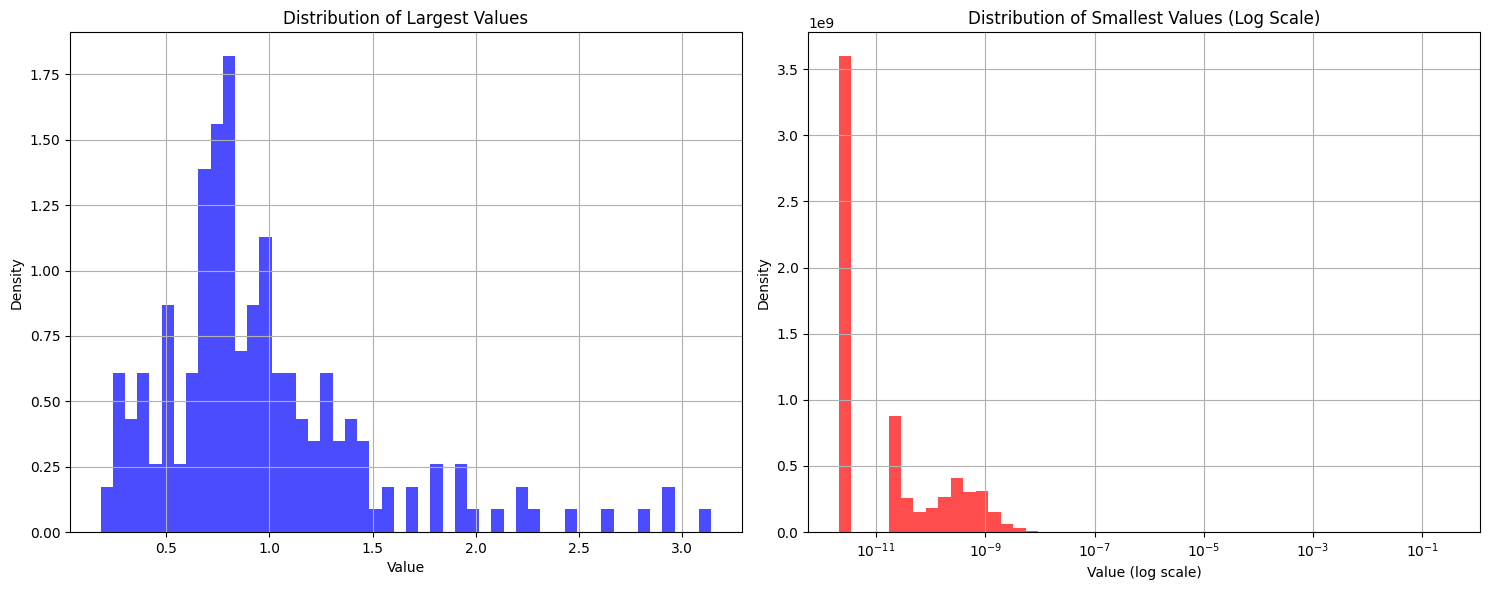

In [23]:
# Create figure with two subplots side by side
plt.figure(figsize=(15, 6))

# First histogram - largest values
plt.subplot(1, 2, 1)
plt.hist(largest, bins=50, density=True, color='blue', alpha=0.7)
plt.title('Distribution of Largest Values')
plt.xlabel('Value')
plt.ylabel('Density')
plt.grid(True)

# Second histogram - smallest values with log scale
plt.subplot(1, 2, 2)
# Create log-spaced bins
log_bins = np.logspace(np.log10(min(smallest)), np.log10(max(smallest)), 50)
plt.hist(smallest, bins=log_bins, density=True, color='red', alpha=0.7)
plt.xscale('log')
plt.title('Distribution of Smallest Values (Log Scale)')
plt.xlabel('Value (log scale)')
plt.ylabel('Density')
plt.grid(True)

plt.tight_layout()
plt.show()

In [41]:
print(f"min={min(smallest)}")
print(f"max={max(largest)}")

min=2.0605739337042905e-12
max=3.140625


In [11]:

# Assuming you have a model defined as 'model'
writer = SummaryWriter()

for name, param in model.named_parameters():
    if 'weight' in name:
        writer.add_histogram(name, param, global_step=0)

writer.close()

---
### Floating point range

In [2]:
BIAS = 7
EXP_BITS = 4
M_BITS = 3

min_exp = 1 - BIAS
max_exp = 2**(EXP_BITS) - 1 - BIAS

min_subnorm_mant = 2**(-M_BITS)
max_subnorm_mant = sum([2**(-i-1) for i in range(M_BITS)])

min_norm_mant = 1
max_norm_mant = 1 + max_subnorm_mant

def calc_float(exponent, mantissa):
    return mantissa * 2**exponent

min_normal = calc_float(min_exp, min_norm_mant)
max_normal = calc_float(max_exp, max_norm_mant)
min_subnormal = calc_float(min_exp, min_subnorm_mant)
max_subnormal = calc_float(min_exp, max_subnorm_mant)

# Print the results
print(f"{1+EXP_BITS+M_BITS} bit float: "+'0_'+'0'*EXP_BITS+'_'+'0'*M_BITS+f' (bias={BIAS})')
print(f"Min Normal: {min_normal}")
print(f"Max Normal: {max_normal}")
print(f"Min Subnormal: {min_subnormal}")
print(f"Max Subnormal: {max_subnormal}")


8 bit float: 0_0000_000 (bias=7)
Min Normal: 0.015625
Max Normal: 480.0
Min Subnormal: 0.001953125
Max Subnormal: 0.013671875


In [16]:
Float8(min_normal*min_normal)

Float8(binary='0.0000.000', decimal=0.000244140625, decimal_approx=0.0)

In [8]:
Float8(sqrt(max_subnormal)), Float8(sqrt(min_subnormal))

(Float8(binary='0.0011.110', decimal=0.11692679333668567),
 Float8(binary='0.0010.011', decimal=0.04419417382415922))

In [6]:
Float8(0.12)

Float8(binary='0.0011.111', decimal=0.12)

In [6]:
Float8('00000111')

Float8(binary='00000111', decimal=0.013671875)

In [11]:
def b(x):
    if isinstance(x, Float8):
        x = x.decimal
        return x
z = Float8(0.0)
b(z), z

(0.0, Float8(binary='0.0000.000', decimal=0.0))

In [15]:
Float8('0.0011.111').decimal**2

0.01373291015625